In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [11]:
def process():
    Day,RV,RVU = np.loadtxt('RCV.tbl.txt', skiprows=22, unpack=True)
    return(Day,RV,RVU)

In [12]:
Day, RV, RVU = process()
print(Day[0])


2449676.0632


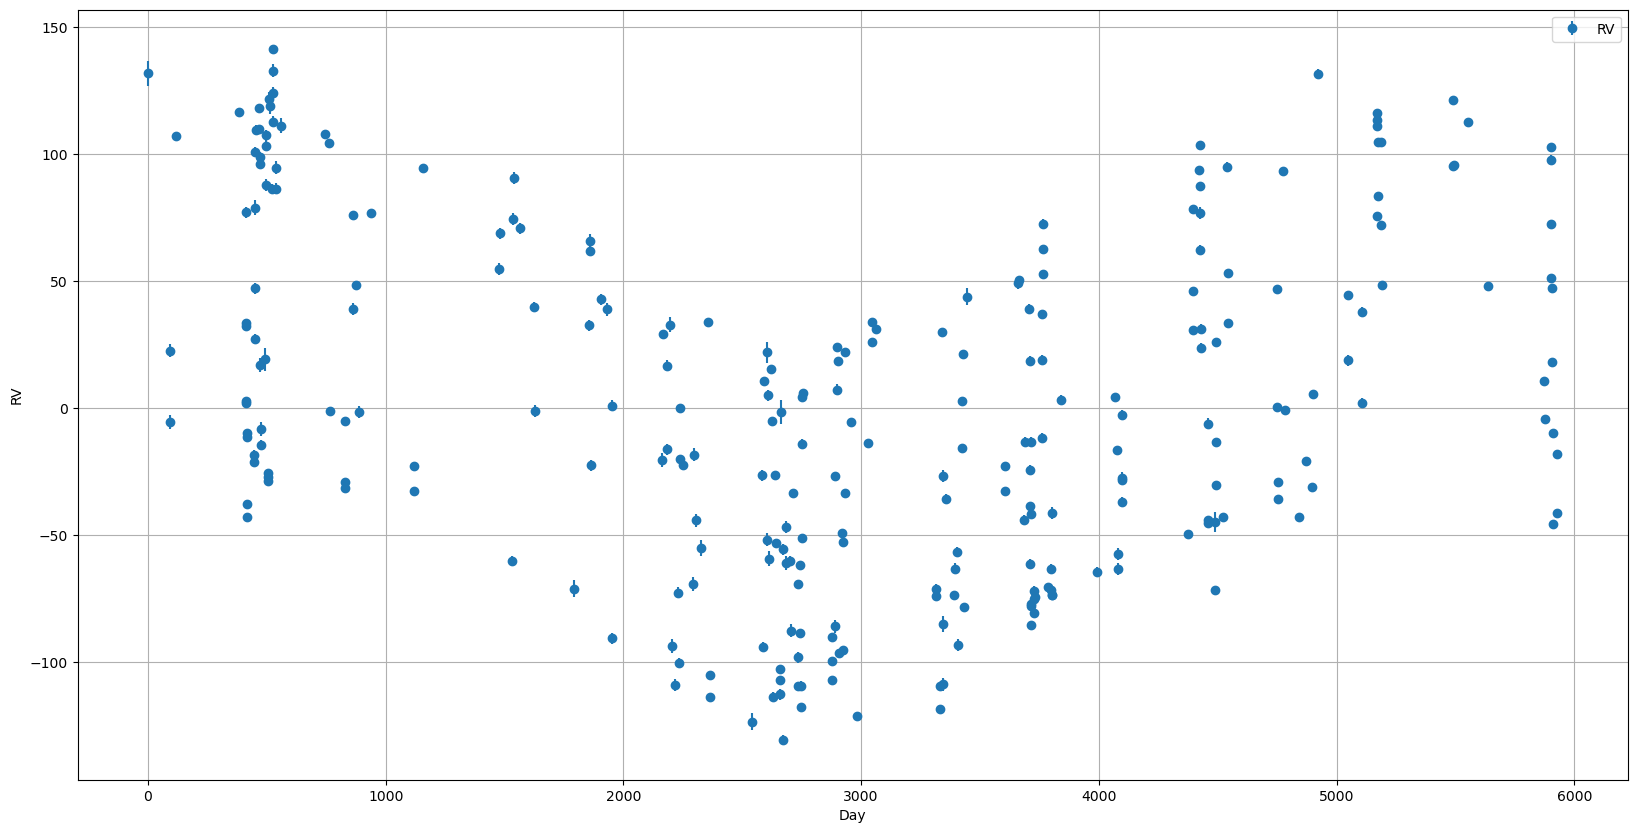

In [13]:
plt.figure(figsize=(20, 10))

plt.errorbar(Day - Day[0], RV, yerr=RVU, fmt='o', label='RV') 
plt.xlabel('Day')
plt.ylabel('RV')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
def f_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

In [20]:
guess_params = [125, -170, 4500, 25]
best_params, _ = optimize.curve_fit(f_model, Day - Day[0], RV, p0=guess_params)
best_a = best_params[0]
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]
print(best_params)

[ 5.43926334e+01 -5.88293606e+02  4.77736097e+03  1.08246696e-01]


In [21]:
x_fit = np.linspace(min(Day - Day[0]), max(Day - Day[0]), 500)
y_fit = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

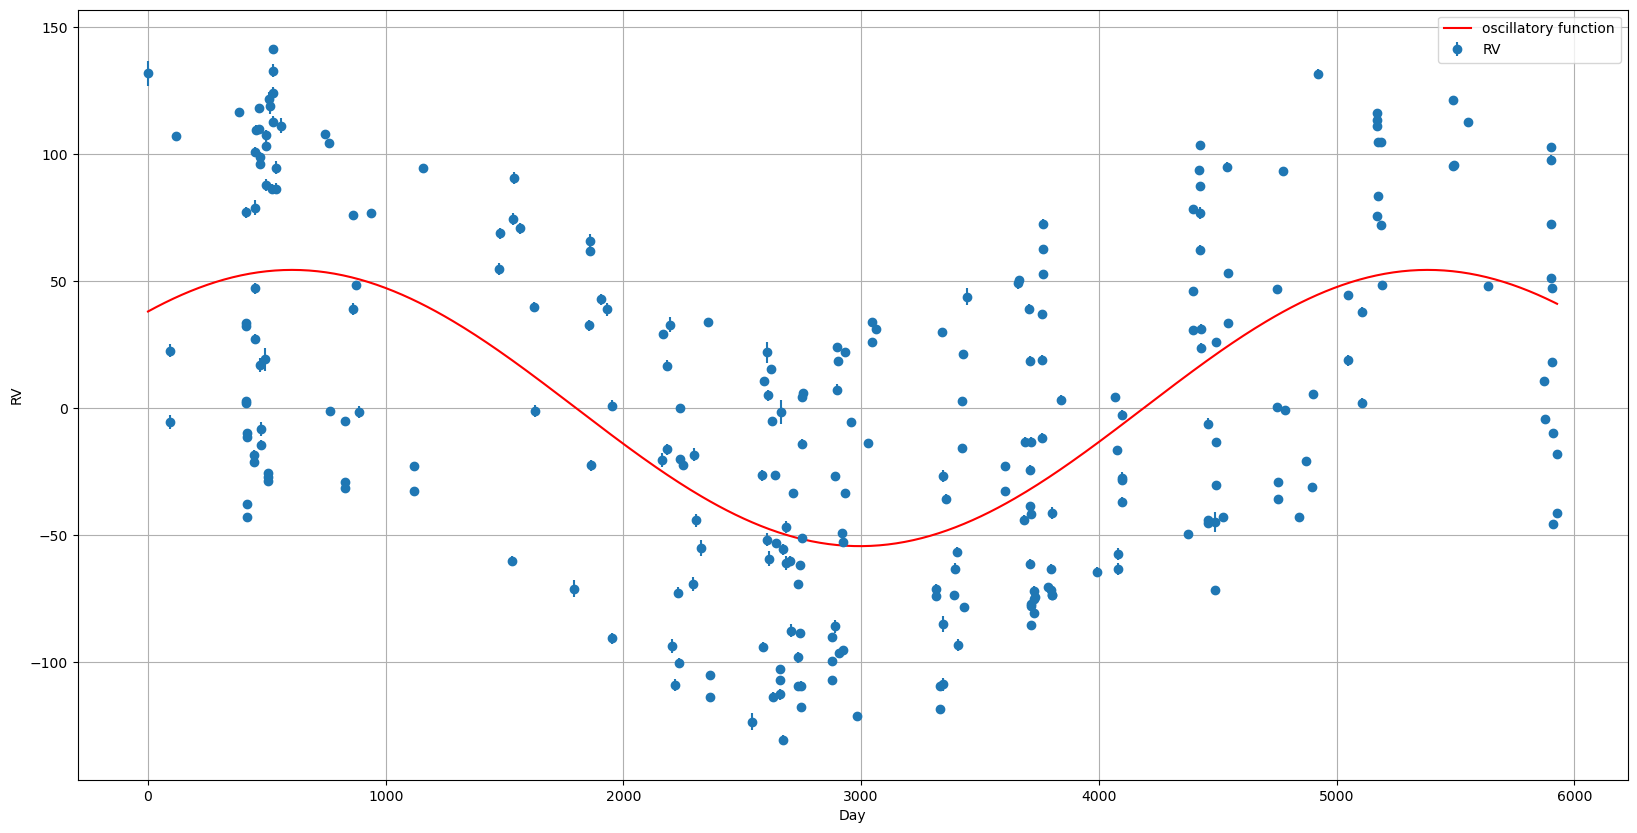

In [22]:
plt.figure(figsize=(20, 10))
plt.errorbar(Day - Day[0], RV, yerr=RVU, fmt='o', label='RV')
plt.plot(x_fit, y_fit, 'r-', label='oscillatory function')
plt.xlabel('Day')
plt.ylabel('RV')
#RV stands for radial velocity
plt.legend()
plt.grid(True)
plt.show()